<a href="https://colab.research.google.com/github/Obanai4you/CSIT-LAB-WORKS/blob/main/Dataware_Housing_And_Datamining/Lab1(dmdw).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DataMining And WareHousing
#LAB1:

### Define Data:
Data refers to raw, unorganized facts, figures, or information that is collected through observations, experiments, or other means. In a computational context, data can be structured (e.g., tables, databases), semi-structured (e.g., JSON, XML), or unstructured (e.g., text, images, audio, video). It is the foundational input for analysis, processing, and decision-making.

### Exploratory Data Analysis (EDA):
Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often with visual methods. It is used to discover patterns, detect anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization techniques. EDA helps analysts understand the data better before formal modeling or hypothesis testing.

### Importance Of EDA:
EDA is crucial because it:

1.  **Uncovers Insights:** Helps identify underlying patterns, relationships, and trends that might not be immediately obvious.
2.  **Identifies Anomalies:** Allows for the detection of outliers, errors, or missing values that can significantly impact analysis.
3.  **Informs Feature Engineering:** Guides the process of creating new features or transforming existing ones for better model performance.
4.  **Assists in Model Selection:** Provides a deeper understanding of data distributions and characteristics, which can inform the choice of appropriate statistical models or machine learning algorithms.
5.  **Validates Assumptions:** Helps verify assumptions about the data that are often made during statistical modeling.
6.  **Communicates Findings:** Facilitates effective communication of data characteristics and insights to stakeholders through visualizations.

##Describe in short about PIIMA dataset that you are going to use.
The heart_ds dataset is a collection of patient data used for predicting heart disease. It contains various clinical attributes such as age, sex, chest pain type (cp), resting blood pressure (trestbps), cholesterol (chol), fasting blood sugar (fbs), resting electrocardiographic results (restecg), maximum heart rate achieved (thalach), exercise-induced angina (exang), ST depression induced by exercise relative to rest (oldpeak), the slope of the peak exercise ST segment (slope), number of major vessels colored by fluoroscopy (ca), and thalassemia (thal), with the ultimate target variable indicating the presence or absence of heart disease.

Through Exploratory Data Analysis (EDA), we've examined the distribution of these features using histograms, identified skewness in variables like chol, fbs, oldpeak, and ca, visualized outliers with box plots (notably in chol and oldpeak), and analyzed the correlations between all features, including their relationships with the target variable, using a heatmap. This EDA helps in understanding the dataset's characteristics, informing potential data preprocessing steps, and guiding subsequent machine learning model selection and development.


In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
import seaborn as sns

In [5]:
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

In [6]:
heart_ds= pd.read_csv('/content/heart.csv', header=None, names=col_names)

In [7]:
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1,52,1,0,125,212,0,1,168,0,1,2,2,3,0
2,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
3,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
4,61,1,0,148,203,0,1,161,0,0,2,1,3,0


##Check dimensions i.e. number of rows and columns in ths dataset

First, let's remove the first row of the DataFrame, which contains the duplicate headers. This will ensure our analysis is based on actual data.

In [8]:
heart_ds = heart_ds.iloc[1:].copy()
heart_ds.reset_index(drop=True, inplace=True)


In [9]:
heart_ds.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [10]:
print(f"Number of rows: {heart_ds.shape[0]}")
print(f"Number of columns: {heart_ds.shape[1]}")
print(f"Dimensions of the dataset: {heart_ds.shape}")

Number of rows: 1025
Number of columns: 14
Dimensions of the dataset: (1025, 14)


In [11]:
heart_ds.groupby('target').size()

,0
target,
0,499
1,526


#View statistical details about the data

In [12]:
heart_ds.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025,1025,1025,1025,1025,1025,1025,1025,1025,1025,1025,1025,1025,1025
unique,41,2,4,49,152,2,3,91,2,40,3,5,4,2
top,58,1,0,120,204,0,1,162,0,0,1,0,2,1
freq,68,713,497,128,21,872,513,35,680,329,482,578,544,526


In [13]:
heart_ds.describe().T

,count,unique,top,freq
age,1025,41,58,68
sex,1025,2,1,713
cp,1025,4,0,497
trestbps,1025,49,120,128
chol,1025,152,204,21
fbs,1025,2,0,872
restecg,1025,3,1,513
thalach,1025,91,162,35
exang,1025,2,0,680
oldpeak,1025,40,0,329


##Exploratory Data Analysis (EDA) - A preliminary examination of the dataset to better understand its patterns and properties through visualization.

Histogram - here we look at the distribution of each attribute by discretizing the continuous values into buckets and  count the frequency  in each bucket as histograms.

> Histogram is formed by couting the frequency of each  values in the attribute and then plotting it as bargraph.

#### This lets us note interesting properties of the attribute distributions such as the possible normal distribution of attributes  associated with the features of the dataset or skewness of the data feature.

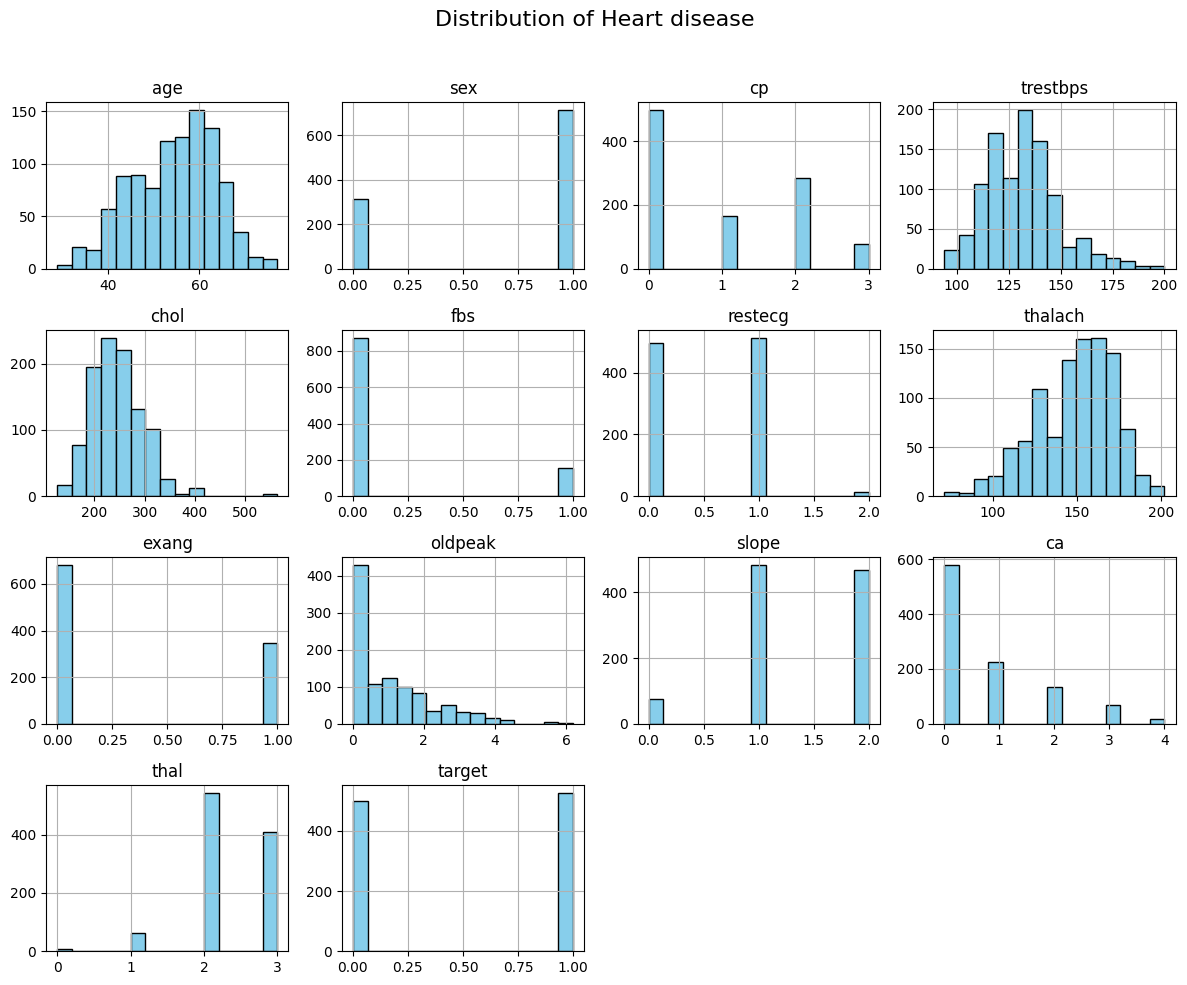

In [24]:
for col in heart_ds.columns:
    # Attempt to convert to numeric, coercing errors to NaN
    heart_ds[col] = pd.to_numeric(heart_ds[col], errors='coerce')
    # Optionally, fill NaNs or handle them appropriately if they arise from conversion
    # For simplicity here, we'll assume valid numeric data or let hist ignore NaNs

# Create histograms for all numeric columns -
heart_ds.hist(figsize=(12, 10),
                bins=15,
                color='skyblue',
                edgecolor='black')

plt.suptitle("Distribution of Heart disease", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Histogram Data Interpretation of each attributes above

### Each picture above is a histogram  that shows the distribution of  each feature or attibute. Each figure represents a univariate distribution. i.e. involving only one variable or feature.

### <font color = green> Certain insights from the histogram plot </font>


1.  **Distribution Type**: We can identify features like 'age' and 'chol' as roughly normally distributed, while 'oldpeak' shows a clear right-skewed distribution.
2.  **Missing Value Imputation**: For normally distributed features like 'age', missing values can be replaced by the **mean**. For skewed features like 'oldpeak', the **median** would be a more appropriate choice.
3.  **Machine Learning Impact**: Many models perform best with normally distributed data. For skewed features like 'oldpeak', transformations (e.g., log, square root) can make the distribution more normal, improving model accuracy and reducing bias in predictions, especially for extreme values.

###Check the skewness degree of each atribute. Values near zero are less skewed as compared to values away from it. Distribtuions that have skewness value less than -1 or greater than +1 are skewed.

In [26]:
print("Skewness values of each attribute:")
skewness_values = heart_ds.skew()
print(skewness_values)

Skewness values of each attribute:
age        -0.248866
sex        -0.851449
cp          0.529455
trestbps    0.739768
chol        1.074073
fbs         1.971339
restecg     0.180440
thalach    -0.513777
exang       0.692655
oldpeak     1.210899
slope      -0.479134
ca          1.261189
thal       -0.524390
target     -0.052778
dtype: float64


###Data Interpretation of above result: From the above skew values, we found that features like age, sex, cp, trestbps, restecg, thalach, exang, slope, thal, and target are relatively normally distributed (as their skewness values are between -1 and +1). While features such as chol, fbs, oldpeak, and ca are significantly skewed (all show right-skewness, with values greater than +1).

### Additional Histogram Insights & Theory (Short):

Below figure shows there's lot more observations for one class than another and may need special handling in the data preparation

In [28]:
output_grp_heart = heart_ds.groupby('target').size()
print("Count of observations per target class:")
print(output_grp_heart)

Count of observations per target class:
target
0    499
1    526
dtype: int64


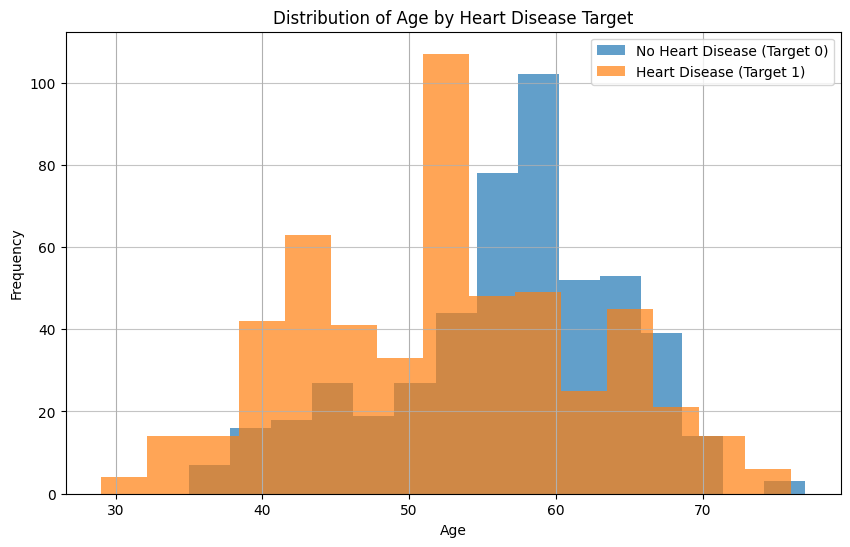

In [29]:
plt.figure(figsize=(10, 6))
heart_ds.groupby('target')['age'].hist(alpha=0.7, bins=15, legend=True)
plt.title('Distribution of Age by Heart Disease Target')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['No Heart Disease (Target 0)', 'Heart Disease (Target 1)'])
plt.grid(axis='y', alpha=0.75)
plt.show()

## Interpretation of Target Class Balance and Age Distribution

**1. Target Class Balance:**
As confirmed by `heart_ds.groupby('target').size()`:
*   **Target 0 (No Heart Disease):** 499 observations
*   **Target 1 (Heart Disease):** 526 observations

This shows a very **well-balanced** distribution between the two target classes. This is ideal for classification tasks as it typically means models can learn effectively from both positive and negative cases without bias towards a majority class.

**2. Age Distribution by Target Class:**
The histogram of 'age' grouped by the 'target' variable reveals the age ranges for individuals with and without heart disease:
*   The distributions for both groups overlap significantly, indicating that heart disease can occur across a wide range of ages.
*   However, there appears to be a slightly higher frequency of individuals with heart disease (Target 1) in the middle-to-older age groups compared to those without (Target 0), suggesting age is a factor, but not a clear-cut determinant.
*   Both distributions generally show a bell-like shape, centered around the 50s and 60s.

###The well-balanced target variable ensures robust model training, preventing bias and promoting accurate predictions without special class handling.

#Box-Plot
 Visualize data distritbution's median as thick line within the box, interquartile range with 25th percentile as left most boundary and  75th percetnile as right most boundary. Data outisde of these interquartile range are considered outliers.

 From the diagram below, 'Cholesterol' (chol) and 'Oldpeak' (oldpeak) show the most prominent outliers, while 'Sex' (sex) and 'Resting Electrocardiographic Results' (restecg) have very few.

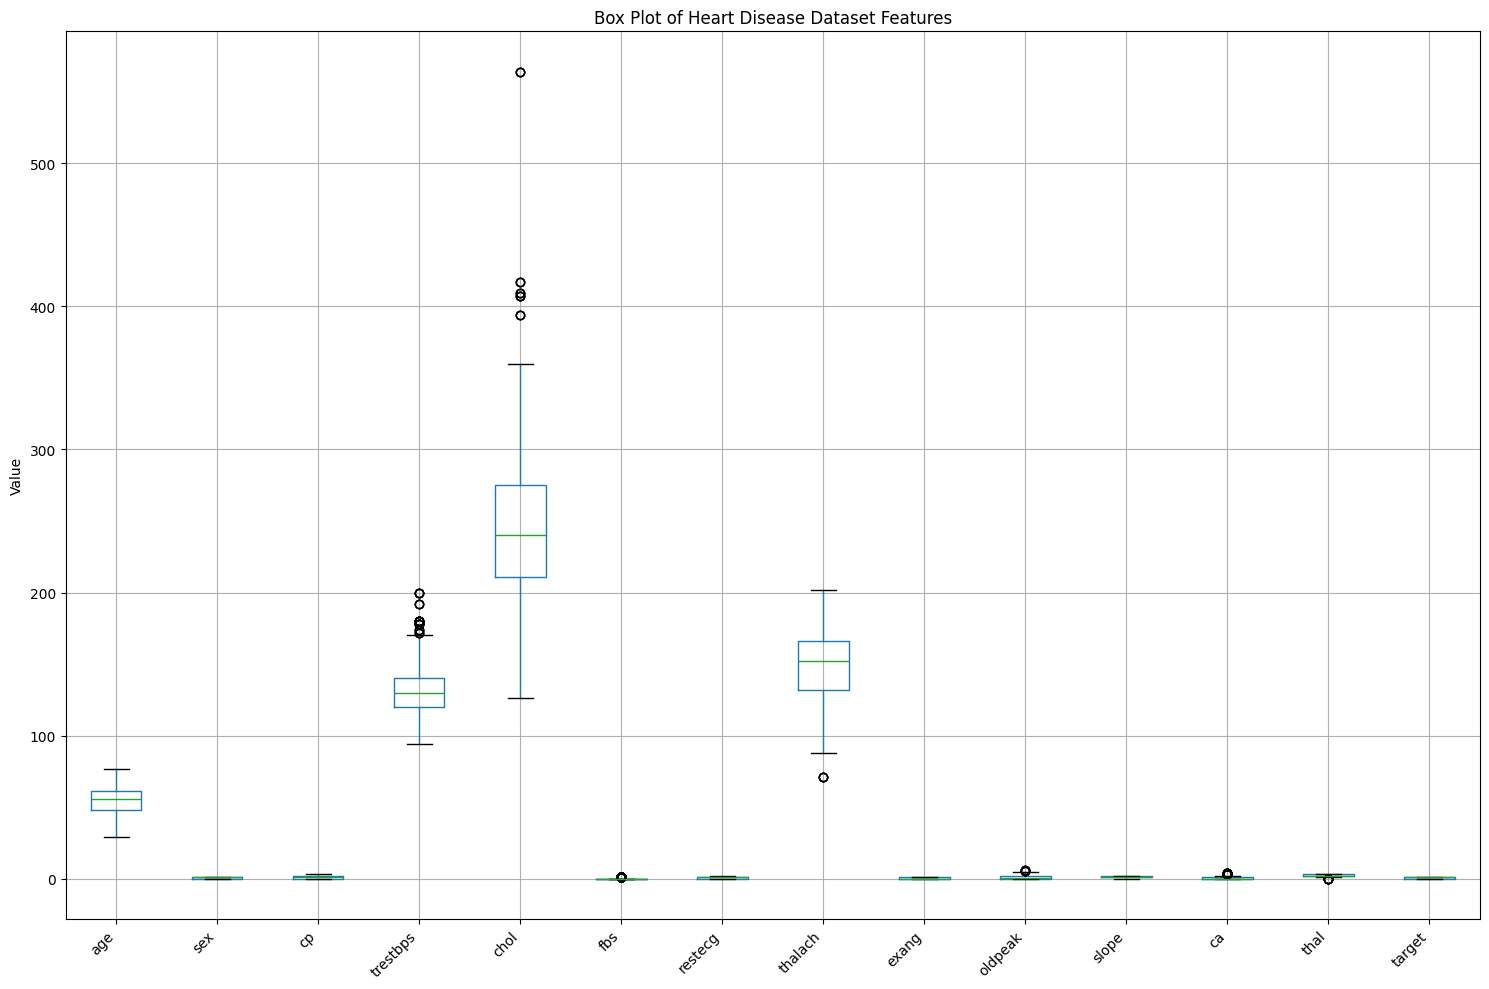

Box plot of heart_ds dataset generated.


In [30]:
plt.figure(figsize=(15, 10))
heart_ds.boxplot()
plt.title('Box Plot of Heart Disease Dataset Features')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Box plot of heart_ds dataset generated.")

## Heatmap Plot
****
Identifying correlation between two attributes, values nearer to +1 represents stronger linear relationship between two variables while values nearer to  -1 represents  inverse relation.

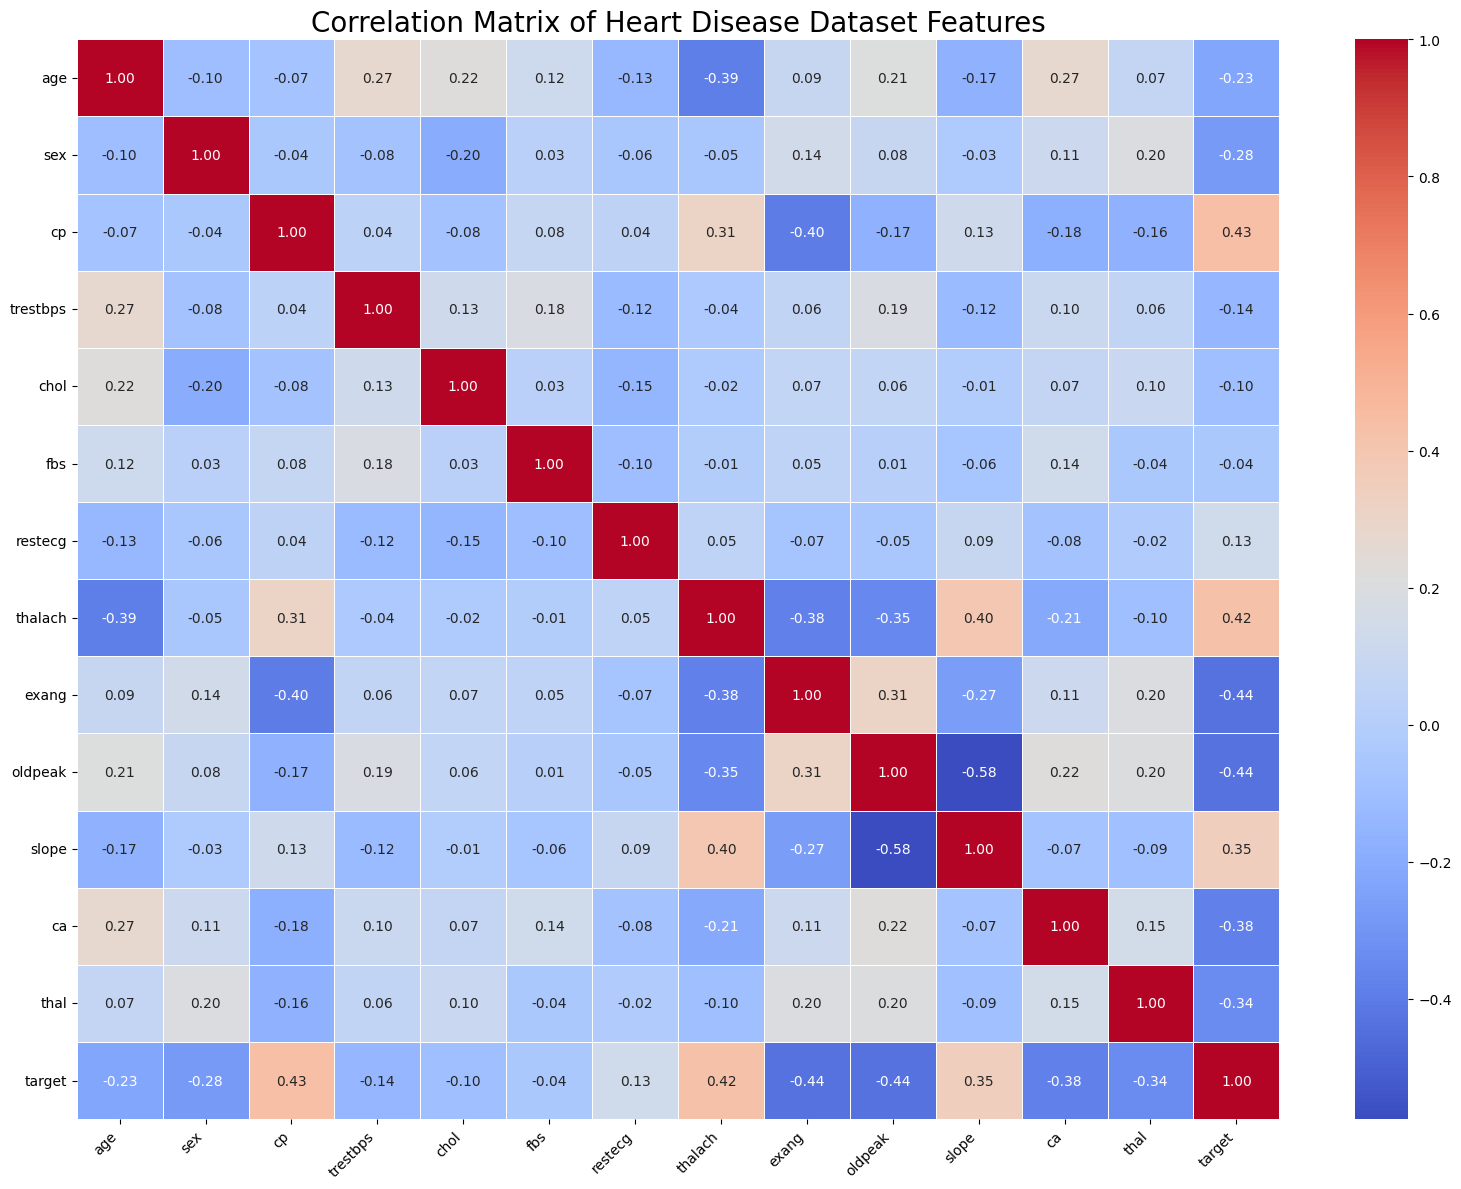

In [31]:
# Calculate the correlation matrix
correlation_matrix = heart_ds.corr()

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Heart Disease Dataset Features', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation of the Correlation Heatmap

This heatmap visually represents the pairwise correlation coefficients between all features in your dataset. Here are some key observations:

1.  **Correlations with `target` variable:** Look at the last row (or column) for `target`. Positive values indicate features that increase the likelihood of heart disease, while negative values indicate features that decrease it. For example, `cp` (chest pain type) and `thalach` (maximum heart rate achieved) show positive correlations with `target`, while `exang` (exercise induced angina) and `oldpeak` show negative correlations.

2.  **Inter-feature correlations:** Examine the correlations between other features. High positive or negative correlations between independent features might indicate multicollinearity, which can be important for some machine learning models. For instance, `age` and `trestbps` (resting blood pressure) show a moderate positive correlation.

3.  **Strongest Correlations:** Features with correlation coefficients closer to 1 or -1 have stronger linear relationships. Features with values near 0 have weak or no linear relationship.

This visualization is a powerful tool in EDA to quickly grasp the relationships within your data and can guide feature selection or engineering for predictive modeling.